In [1]:
# chain using langgraph 
# in this section we will see how we can build a simple chain using langgraph that uses 4 important concepts
# how to use chat messages as our graph state
# how to use chat models in graph nodes.
# how to bind tools to our LLM in chat models
# how to execute the tools call in our graph nodes

In [2]:
from dotenv import load_dotenv
load_dotenv()


import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

python-dotenv could not parse statement starting at line 8


In [3]:
# how to use chat messages as our grpah state
# messages
# we can use messages which can be used ot capture different roles within a conversation. langchain has various message types 
# including humman Message , AI Message , SystemMessage  and toolmessage
# these represent a message from the user, from cat model, for the chat model to instruct behavior, and from at tool call

# every message have these important components.

# content - content of the message
# name - Specify the name of author
# response_metadata - optinally , a dict of metadata (eg. often populated by model provider for AIMessage)

In [4]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages = [AIMessage(content = f"Please tell me how can I help", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding", name = "Harshit"))

messages.append(AIMessage(content = f"which programing language you want to learn", name="LLMModel"))

messages.append(HumanMessage(content=f"I want to learn python programing language", name = "Harshit"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Harshit

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

which programing language you want to learn
================================ Human Message =================================
Name: Harshit

I want to learn python programing language


In [5]:
# chat models
# we can use the sequence of message as input with the catmodels using LLM's and OPENAI.



In [6]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")

result = llm.invoke(messages)

In [7]:
result.response_metadata

{'token_usage': {'completion_tokens': 1712,
  'prompt_tokens': 56,
  'total_tokens': 1768,
  'completion_time': 5.10654564,
  'completion_tokens_details': None,
  'prompt_time': 0.002203281,
  'prompt_tokens_details': None,
  'queue_time': 0.055606025,
  'total_time': 5.108748921},
 'model_name': 'qwen/qwen3-32b',
 'system_fingerprint': 'fp_5cf921caa2',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

In [8]:
result.pretty_print()

================================== Ai Message ==================================

<think>
Okay, the user wants to learn Python. Let me start by breaking down the steps. First, they need to install Python. I should mention the official website and maybe the latest version. Oh, and the package manager pip is important too.

Next, the basics. Variables, data types, control structures. Maybe suggest an interactive platform like Replit or Jupyter for practice. Oh, and code editors like VS Code or PyCharm. Should I recommend one over the other? Maybe VS Code for its popularity and extensions.

Then, moving on to functions and modules. Projects are key here. Simple projects like a calculator or guessing game can help apply what they've learned. Oh, and mention the importance of practicing regularly.

Data structures and algorithms come next. Lists, dictionaries, tuples, sets. Sorting, searching algorithms. Maybe suggest using platforms like LeetCode or HackerRank for practice.

Web developmen

In [9]:
# Tools
# Tools can be integrated with the LLM models to interact with external systems. External systems can be API's , third pary tools.
# whenever a query is asked the model can choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema

In [10]:
def add(a: int,b: int) -> int:
    """Add a and b
    Args : 
        a (int) : first int
        b (int): Second int

    Returns:
        int  
    """
    return a+b

In [11]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021739019E50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002173A366390>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
# binding tool with llm

llm_with_tools = llm.bind_tools([add])

tool_call =llm_with_tools.invoke([HumanMessage(content=f"what is 2 plus 2",name="Harshit")])

In [13]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'exvb5zyf4',
  'type': 'tool_call'}]

In [14]:
# using message as state 

In [15]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage


class State(TypedDict):
    message:list[AnyMessage]

In [16]:
# reducers 

In [17]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [18]:
# Reducers with add_messages

In [19]:
initial_messages = [AIMessage(content = f"Please tell me how can I help", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding", name = "Harshit"))


In [20]:
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Harshit')]

In [21]:
ai_message = AIMessage(content = f"which programing language you want to learn", name="LLMModel")
ai_message


AIMessage(content='which programing language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [22]:
# Reducers andd_messages is ot append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='15d49ff9-e9d8-4c04-92b2-628593da87be', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Harshit', id='74b5ac02-2af2-4b54-a390-e4f0a9d8bba4'),
 AIMessage(content='which programing language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='a2f15d18-dbf3-4a5e-a485-57f0e2672e8f', tool_calls=[], invalid_tool_calls=[])]

In [23]:
# chat bot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}




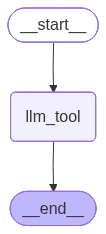

In [24]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

builder = StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
# invocation

messages = graph.invoke({"messages":"what is 2 plus 2"})

In [26]:
for message in messages["messages"]:
    message.pretty_print()
    

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (mghcyvtrz)
 Call ID: mghcyvtrz
  Args:
    a: 2
    b: 2


In [28]:
tools = [add]

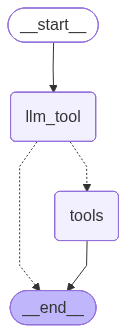

In [29]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)


# Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

# Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges("llm_tool",
                            #   if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
                            # If the latest message (result) from assistant is a not a tool call -> tool_condition routes to END
                              tools_condition)


builder.add_edge("tools",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# invocation

messages = graph.invoke({"messages":"what is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()
    

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (hg0e4hecq)
 Call ID: hg0e4hecq
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


In [31]:

messages = graph.invoke({"messages":"what is machine learning"})

for message in messages["messages"]:
    message.pretty_print()
    

================================ Human Message =================================

what is machine learning
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to learn patterns and make decisions from data without being explicitly programmed for specific tasks. Instead of relying on rigid instructions, machine learning systems improve their performance over time by analyzing examples (training data) and adjusting their parameters accordingly.

### Key Concepts:
1. **Training Data**: The dataset used to teach the model patterns or relationships.
2. **Algorithms**: Techniques like decision trees, neural networks, or support vector machines that process data and learn.
3. **Types of Learning**:
   - **Supervised Learning**: Uses labeled data (input + desired output) to predict outcomes (e.g., classification, regressio